# Cross-Visit Generalization & Momentum Slope Stability

Two questions:
1. **Cross-visit generalization**: Does a late-fusion model trained on visit-1 data predict visit-2 choices, vs. a model trained on visit-2 data itself (within-visit LOSO baseline)? If it does, decision signatures are stable traits. If not, strategies shifted between sessions.
2. **Momentum slope stability**: Subjects differ in how sensitive they are to recent investment momentum (significant random slopes in LMM). Do those individual slopes stay stable from visit 1 → visit 2, or do they drift?

**Data structure**: `user_id` in session_mapping is the desktop/hardware ID (only 3 unique values), not individual people. The real repeated unit is **team members** — a team of ~3 people returns for visit 2. All 34 visit-2 subject sessions come from the 12 teams that also had a visit-1 session. Each `subject_id` (mmdd_hhmm_userid) uniquely identifies one person's session.

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf

from src.utils.io import load_features

RESULTS_DIR = Path('../../data/results/main/cross_visit')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TIMEFRAME = 'PRE'
RANDOM_STATE = 42

## 1. Load Data

In [2]:
feature_data = load_features(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', timeframe=TIMEFRAME)

df = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Add visit info
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']

df = df.merge(sm[['subject_id', 'visit_number', 'team']], on='subject_id', how='left')

print(f"Total trials: {len(df)}, subjects: {df['subject_id'].nunique()}")
print("Trials per visit:")
print(df['visit_number'].value_counts().sort_index())
print(f"\nNaN visit: {df['visit_number'].isna().sum()} trials")

Total trials: 12107, subjects: 102
Trials per visit:
visit_number
1.0    5780
2.0    3870
3.0     939
Name: count, dtype: int64

NaN visit: 1518 trials


In [3]:
# Teams that appear in both visit 1 and visit 2
teams_v1 = set(sm[sm['visit_number'] == 1.0]['team'].dropna())
teams_v2 = set(sm[sm['visit_number'] == 2.0]['team'].dropna())
repeated_teams = sorted(teams_v1 & teams_v2)

print(f"Teams with visit 1 only: {len(teams_v1 - teams_v2)}")
print(f"Teams with both visit 1 and 2: {len(repeated_teams)}")
print(f"Repeated teams: {repeated_teams}")

v1 = df[df['visit_number'] == 1.0].copy()
v2 = df[df['visit_number'] == 2.0].copy()
v2_repeat = v2[v2['team'].isin(repeated_teams)].copy()

print(f"\nVisit 1: {v1['subject_id'].nunique()} subjects, {len(v1)} trials")
print(f"Visit 2 (repeated teams): {v2_repeat['subject_id'].nunique()} subjects, {len(v2_repeat)} trials")

Teams with visit 1 only: 6
Teams with both visit 1 and 2: 12
Repeated teams: ['Team 12', 'Team 15', 'Team 16', 'Team 17', 'Team 18', 'Team 20', 'Team 21', 'Team 22', 'Team 23', 'Team 24', 'Team 25', 'Team 26']

Visit 1: 48 subjects, 5780 trials
Visit 2 (repeated teams): 34 subjects, 3870 trials


## 2. Cross-Visit Generalization

**Design**:
- **Baseline**: LOSO on visit-2 data only (how well can visit-2 subjects predict each other)
- **Cross-visit**: Train on all visit-1 data, test on each visit-2 subject individually
- **Oracle**: LOSO on visit-1 data (upper-bound reference)

If cross-visit ≈ baseline, decision signatures generalize across sessions. If cross-visit < baseline, the model needs to see visit-2 data to capture within-session drift.

In [4]:
def make_features(sub_df, physio_cols, behavior_cols, gaze_cols):
    imp = SimpleImputer(strategy='mean')
    X = imp.fit_transform(sub_df[physio_cols + behavior_cols + gaze_cols])
    y = sub_df['outcome'].values
    subjects = sub_df['subject_id'].values
    return X, y, subjects


def run_loso(X, y, subjects, random_state=RANDOM_STATE):
    logo = LeaveOneGroupOut()
    all_true, all_pred, subj_accs = [], [], []
    unique_subjs = np.unique(subjects)

    for train_idx, test_idx in logo.split(X, y, subjects):
        clf = RandomForestClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=random_state, n_jobs=-1
        )
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        all_true.extend(y[test_idx])
        all_pred.extend(pred)
        subj_accs.append({
            'subject_id': subjects[test_idx[0]],
            'accuracy': accuracy_score(y[test_idx], pred),
            'n_trials': len(test_idx)
        })

    return {
        'accuracy': accuracy_score(all_true, all_pred),
        'f1': f1_score(all_true, all_pred, average='weighted'),
        'subject_df': pd.DataFrame(subj_accs)
    }

In [5]:
# --- Oracle: LOSO on visit 1 ---
X1, y1, s1 = make_features(v1, physio_cols, behavior_cols, gaze_cols)
print("Running LOSO on visit 1 (oracle)...")
res_v1 = run_loso(X1, y1, s1)
print(f"  Visit 1 LOSO accuracy: {res_v1['accuracy']:.4f}, F1: {res_v1['f1']:.4f}")

# --- Baseline: LOSO on visit 2 ---
X2, y2, s2 = make_features(v2_repeat, physio_cols, behavior_cols, gaze_cols)
print("Running LOSO on visit 2 (baseline)...")
res_v2 = run_loso(X2, y2, s2)
print(f"  Visit 2 LOSO accuracy: {res_v2['accuracy']:.4f}, F1: {res_v2['f1']:.4f}")

Running LOSO on visit 1 (oracle)...
  Visit 1 LOSO accuracy: 0.7346, F1: 0.7206
Running LOSO on visit 2 (baseline)...
  Visit 2 LOSO accuracy: 0.7395, F1: 0.7106


In [6]:
# --- Cross-visit: train on visit 1, test each visit-2 subject ---
print("Running cross-visit (train V1 → test V2 subjects)...")

imp_full = SimpleImputer(strategy='mean')
X1_full = imp_full.fit_transform(v1[physio_cols + behavior_cols + gaze_cols])
y1_full = v1['outcome'].values

# Train one model on ALL visit-1 data
clf_cross = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
clf_cross.fit(X1_full, y1_full)

# Test on each visit-2 subject individually
cross_subj = []
imp_v2 = SimpleImputer(strategy='mean')
X2_full = imp_v2.fit_transform(v2_repeat[physio_cols + behavior_cols + gaze_cols])

for subj in v2_repeat['subject_id'].unique():
    mask = v2_repeat['subject_id'].values == subj
    y_s = v2_repeat['outcome'].values[mask]
    X_s = X2_full[mask]
    pred_s = clf_cross.predict(X_s)
    cross_subj.append({
        'subject_id': subj,
        'team': v2_repeat[v2_repeat['subject_id'] == subj]['team'].values[0],
        'accuracy_cross': accuracy_score(y_s, pred_s),
        'n_trials': len(y_s)
    })

cross_df = pd.DataFrame(cross_subj)
cross_acc_overall = accuracy_score(
    v2_repeat['outcome'].values,
    clf_cross.predict(X2_full)
)
print(f"  Cross-visit accuracy (aggregate): {cross_acc_overall:.4f}")
print(f"  Cross-visit accuracy (mean subject): {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].std():.4f}")

Running cross-visit (train V1 → test V2 subjects)...
  Cross-visit accuracy (aggregate): 0.7612
  Cross-visit accuracy (mean subject): 0.7622 ± 0.1449


In [7]:
# Merge cross-visit and within-v2 LOSO subject accuracies for comparison
compare_df = cross_df.merge(
    res_v2['subject_df'].rename(columns={'accuracy': 'accuracy_within_v2'}),
    on='subject_id'
)

compare_df['delta'] = compare_df['accuracy_cross'] - compare_df['accuracy_within_v2']

t_stat, p_val = stats.ttest_rel(compare_df['accuracy_cross'], compare_df['accuracy_within_v2'])
print(f"Paired t-test (cross-visit vs within-v2 LOSO): t={t_stat:.3f}, p={p_val:.4f}")
print(f"Mean delta (cross - within): {compare_df['delta'].mean():.4f} ± {compare_df['delta'].std():.4f}")
print(compare_df[['subject_id', 'team', 'accuracy_cross', 'accuracy_within_v2', 'delta', 'n_trials_x']].sort_values('delta').to_string())

Paired t-test (cross-visit vs within-v2 LOSO): t=1.893, p=0.0672
Mean delta (cross - within): 0.0165 ± 0.0509
           subject_id     team  accuracy_cross  accuracy_within_v2     delta  n_trials_x
7   0825_1000_9M4VCHG  Team 17        0.555556            0.666667 -0.111111           9
5   0823_1400_U9TEJGM  Team 15        0.569106            0.626016 -0.056911         123
13  0831_1300_539136F  Team 21        0.800000            0.830769 -0.030769         130
6   0825_1000_539136F  Team 17        0.891892            0.918919 -0.027027          37
29  0930_1700_9M4VCHG  Team 25        0.714286            0.741071 -0.026786         112
19  0917_1030_539136F  Team 22        0.610687            0.633588 -0.022901         131
2   0816_1400_U9TEJGM  Team 12        0.648000            0.656000 -0.008000         125
24  0923_1000_U9TEJGM  Team 23        0.765625            0.773438 -0.007812         128
23  0923_1000_9M4VCHG  Team 23        0.931298            0.938931 -0.007634         131


In [8]:
# Also add visit-1 LOSO per-subject accuracy for the same teams
v1_team_subj = res_v1['subject_df'].copy()
v1_team_subj = v1_team_subj.merge(sm[['subject_id','team']], on='subject_id', how='left')
v1_repeated_teams_acc = v1_team_subj[v1_team_subj['team'].isin(repeated_teams)]

print("\nVisit-1 LOSO accuracy (repeated teams only):")
print(f"  Mean: {v1_repeated_teams_acc['accuracy'].mean():.4f} ± {v1_repeated_teams_acc['accuracy'].std():.4f}")
print(f"\nSummary table:")
print(f"  V1 LOSO (repeated teams): {v1_repeated_teams_acc['accuracy'].mean():.4f}")
print(f"  V2 LOSO (within-visit):   {res_v2['subject_df']['accuracy'].mean():.4f}")
print(f"  Cross-visit (V1→V2):      {cross_df['accuracy_cross'].mean():.4f}")


Visit-1 LOSO accuracy (repeated teams only):
  Mean: 0.7355 ± 0.1262

Summary table:
  V1 LOSO (repeated teams): 0.7355
  V2 LOSO (within-visit):   0.7456
  Cross-visit (V1→V2):      0.7622


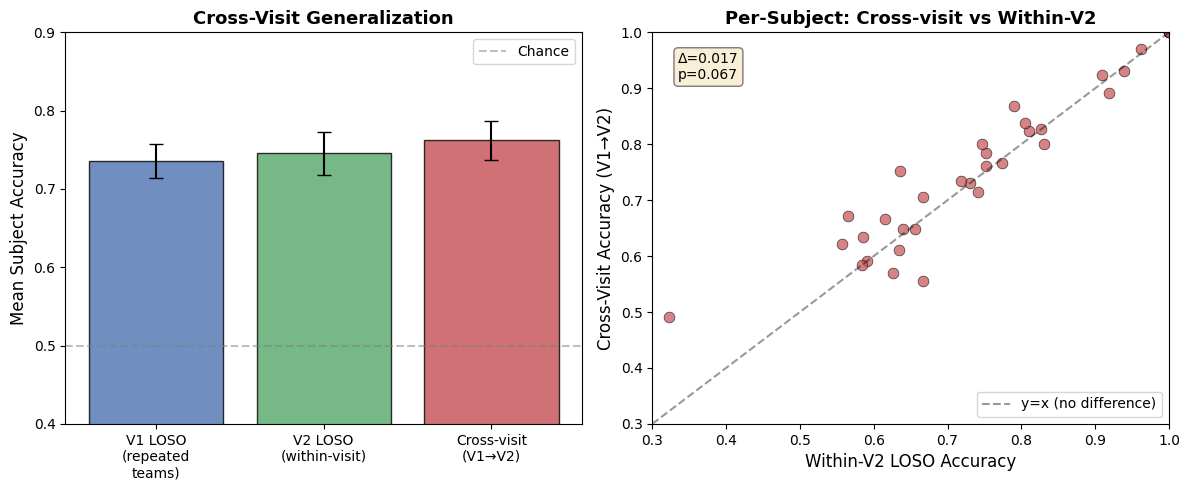

Saved figure.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: summary bar chart
ax = axes[0]
labels = ['V1 LOSO\n(repeated\nteams)', 'V2 LOSO\n(within-visit)', 'Cross-visit\n(V1→V2)']
means = [
    v1_repeated_teams_acc['accuracy'].mean(),
    res_v2['subject_df']['accuracy'].mean(),
    cross_df['accuracy_cross'].mean()
]
sems = [
    v1_repeated_teams_acc['accuracy'].sem(),
    res_v2['subject_df']['accuracy'].sem(),
    cross_df['accuracy_cross'].sem()
]
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(labels, means, yerr=sems, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylabel('Mean Subject Accuracy', fontsize=12)
ax.set_title('Cross-Visit Generalization', fontsize=13, fontweight='bold')
ax.set_ylim(0.4, 0.9)
ax.legend()

# Panel B: subject-level scatter (cross-visit vs within-v2)
ax = axes[1]
ax.scatter(compare_df['accuracy_within_v2'], compare_df['accuracy_cross'],
           alpha=0.7, s=60, color='#C44E52', edgecolors='black', linewidth=0.5)
lims = [0.3, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.4, label='y=x (no difference)')
ax.set_xlabel('Within-V2 LOSO Accuracy', fontsize=12)
ax.set_ylabel('Cross-Visit Accuracy (V1→V2)', fontsize=12)
ax.set_title('Per-Subject: Cross-visit vs Within-V2', fontsize=13, fontweight='bold')
ax.set_xlim(lims)
ax.set_ylim(lims)

# Annotate with t-test
ax.text(0.05, 0.95, f'Δ={compare_df["delta"].mean():.3f}\np={p_val:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cross_visit_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

## 3. Momentum Slope Stability Across Visits

The LMM in notebook 11 found that subjects differ significantly in their sensitivity to `running_invest_rate` (momentum). Here we:
1. Fit the same LMM separately for visit-1 and visit-2 sessions
2. Extract each subject's random slope (momentum sensitivity) at each visit
3. Correlate visit-1 slopes with visit-2 slopes to measure stability

Stable slopes → momentum sensitivity is a trait. Unstable → it's learned/adapted within session.

Since each `subject_id` is a unique session, we use `team` + `desktop_id` as the across-visit link.

In [10]:
# Add desktop_id from user_id portion of subject_id
df['desktop_id'] = df['subject_id'].str.split('_').str[2]

# Sequential features needed for LMM
lmm_cols = [
    'outcome', 'subject_id', 'team', 'desktop_id', 'visit_number',
    'running_invest_rate', 'recent_invest_rate_5', 'consecutive_same',
    'prev_outcome', 'trial_position',
    'ev_difference', 'ambiguity', 'risk_premium', 'decision_time'
]

lmm_df = df[lmm_cols].dropna().copy()
print(f"LMM dataset: {len(lmm_df)} trials, {lmm_df['subject_id'].nunique()} subjects")

# Z-score continuous predictors globally (so slopes are comparable across visits)
cont_cols = [
    'running_invest_rate', 'recent_invest_rate_5', 'consecutive_same',
    'trial_position', 'ev_difference', 'ambiguity', 'risk_premium', 'decision_time'
]
for col in cont_cols:
    mu, sd = lmm_df[col].mean(), lmm_df[col].std()
    lmm_df[f'{col}_z'] = (lmm_df[col] - mu) / sd

print("Z-scored predictors added.")

LMM dataset: 10589 trials, 90 subjects
Z-scored predictors added.


In [11]:
formula = (
    'outcome ~ running_invest_rate_z + recent_invest_rate_5_z '
    '+ consecutive_same_z + prev_outcome + trial_position_z '
    '+ ev_difference_z + ambiguity_z + risk_premium_z + decision_time_z'
)

def fit_lmm_with_slopes(data, group_col='subject_id'):
    """Fit LMM with random intercept + slope for running_invest_rate."""
    model = smf.mixedlm(
        formula, data=data,
        groups=data[group_col],
        re_formula='~running_invest_rate_z'
    )
    result = model.fit(reml=False, method='lbfgs')
    return result


def extract_random_slopes(result):
    """Return DataFrame of per-subject random effects: intercept and momentum slope."""
    re = result.random_effects
    rows = []
    for subj, vals in re.items():
        row = {'subject_id': subj}
        if hasattr(vals, 'items'):
            for k, v in vals.items():
                row[k] = v
        else:
            row['intercept'] = float(vals)
        rows.append(row)
    return pd.DataFrame(rows)


print("Fitting LMM on visit-1 data...")
v1_lmm = lmm_df[lmm_df['visit_number'] == 1.0]
# Keep only subjects with ≥10 trials
v1_lmm = v1_lmm[v1_lmm.groupby('subject_id')['subject_id'].transform('count') >= 10]
res_lmm_v1 = fit_lmm_with_slopes(v1_lmm)
print(res_lmm_v1.summary())

Fitting LMM on visit-1 data...
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        outcome   
No. Observations:        5780           Method:                    ML        
No. Groups:              48             Scale:                     0.1763    
Min. group size:         79             Log-Likelihood:            -3264.7761
Max. group size:         132            Converged:                 Yes       
Mean group size:         120.4                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          0.638    0.024  26.775 0.000  0.591  0.685
running_invest_rate_z             -0.048    0.021  -2.230 0.026 -0.090 -0.006
recent_invest_rate_5_z             0.033    0.009   3

/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
print("Fitting LMM on visit-2 data...")
v2_lmm = lmm_df[lmm_df['visit_number'] == 2.0]
v2_lmm = v2_lmm[v2_lmm.groupby('subject_id')['subject_id'].transform('count') >= 10]
res_lmm_v2 = fit_lmm_with_slopes(v2_lmm)
print(res_lmm_v2.summary())

Fitting LMM on visit-2 data...
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        outcome   
No. Observations:        3861           Method:                    ML        
No. Groups:              33             Scale:                     0.1625    
Min. group size:         37             Log-Likelihood:            -2020.4571
Max. group size:         132            Converged:                 Yes       
Mean group size:         117.0                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          0.699    0.033  21.175 0.000  0.634  0.763
running_invest_rate_z              0.012    0.022   0.560 0.575 -0.031  0.056
recent_invest_rate_5_z             0.013    0.012   1

/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [13]:
# Extract random slopes
slopes_v1 = extract_random_slopes(res_lmm_v1)
slopes_v2 = extract_random_slopes(res_lmm_v2)

print("Visit-1 random effects columns:", slopes_v1.columns.tolist())
print(slopes_v1.head())
print("\nVisit-2 random effects columns:", slopes_v2.columns.tolist())

Visit-1 random effects columns: ['subject_id', 'Group', 'running_invest_rate_z']
          subject_id     Group  running_invest_rate_z
0  0806_1000_U9TEJGM -0.106426              -0.047521
1  0813_1000_539136F -0.207322               0.013683
2  0813_1000_9M4VCHG -0.064157               0.006903
3  0813_1000_U9TEJGM -0.118648              -0.063062
4  0813_1600_539136F  0.037990               0.004461

Visit-2 random effects columns: ['subject_id', 'Group', 'running_invest_rate_z']


In [14]:
# Link visit-1 and visit-2 subjects via team + desktop_id
# Each subject_id encodes mmdd_hhmm_desktop. Same person = same team + same desktop_id across visits.
subj_meta = df[['subject_id','team','desktop_id','visit_number']].drop_duplicates()

slopes_v1_meta = slopes_v1.merge(subj_meta, on='subject_id', how='left')
slopes_v2_meta = slopes_v2.merge(subj_meta, on='subject_id', how='left')

# Rename slope column (statsmodels names it 'running_invest_rate_z' or 'Group')
# Identify slope column
slope_col_candidates = [c for c in slopes_v1.columns if 'running' in c.lower() or 'invest' in c.lower()]
intercept_candidates = [c for c in slopes_v1.columns if 'intercept' in c.lower() or c == 'Group']
print("Slope candidates:", slope_col_candidates)
print("Intercept candidates:", intercept_candidates)

if slope_col_candidates:
    slope_col = slope_col_candidates[0]
else:
    # All effects may be in one column if model uses scalar RE
    slope_col = [c for c in slopes_v1.columns if c != 'subject_id'][0]
    
print(f"\nUsing slope column: '{slope_col}'")

Slope candidates: ['running_invest_rate_z']
Intercept candidates: ['Group']

Using slope column: 'running_invest_rate_z'


In [15]:
# Merge v1 and v2 slopes by team + desktop_id
s1_key = slopes_v1_meta[['subject_id','team','desktop_id', slope_col]].copy()
s1_key = s1_key.rename(columns={slope_col: 'slope_v1', 'subject_id': 'subject_v1'})

s2_key = slopes_v2_meta[['subject_id','team','desktop_id', slope_col]].copy()
s2_key = s2_key.rename(columns={slope_col: 'slope_v2', 'subject_id': 'subject_v2'})

# Match: same team + same desktop_id across visits
slope_pairs = s1_key.merge(s2_key, on=['team','desktop_id'], how='inner')
print(f"Matched subject pairs (same person, v1 vs v2): {len(slope_pairs)}")
print(slope_pairs[['subject_v1','subject_v2','team','desktop_id','slope_v1','slope_v2']].to_string())

Matched subject pairs (same person, v1 vs v2): 32
           subject_v1         subject_v2     team desktop_id  slope_v1  slope_v2
0   0813_1600_539136F  0816_1400_539136F  Team 12    539136F  0.004461  0.005882
1   0813_1600_9M4VCHG  0816_1400_9M4VCHG  Team 12    9M4VCHG -0.122050  0.016642
2   0813_1600_U9TEJGM  0816_1400_U9TEJGM  Team 12    U9TEJGM  0.074229 -0.017624
3   0819_1400_539136F  0823_1400_539136F  Team 15    539136F  0.000820 -0.011499
4   0819_1400_9M4VCHG  0823_1400_9M4VCHG  Team 15    9M4VCHG  0.060763  0.011929
5   0819_1400_U9TEJGM  0823_1400_U9TEJGM  Team 15    U9TEJGM  0.068094  0.029732
6   0824_1000_539136F  0825_1000_539136F  Team 17    539136F -0.051381  0.000786
7   0825_1300_539136F  0826_1300_539136F  Team 18    539136F -0.005326 -0.019972
8   0825_1300_9M4VCHG  0826_1300_9M4VCHG  Team 18    9M4VCHG  0.031173 -0.014876
9   0825_1300_U9TEJGM  0826_1300_U9TEJGM  Team 18    U9TEJGM -0.023340  0.000498
10  0827_1000_9M4VCHG  0828_1300_9M4VCHG  Team 16    9M4VCH

In [16]:
if len(slope_pairs) >= 3:
    r, p = stats.pearsonr(slope_pairs['slope_v1'], slope_pairs['slope_v2'])
    r_sp, p_sp = stats.spearmanr(slope_pairs['slope_v1'], slope_pairs['slope_v2'])
    print(f"Momentum slope stability: Pearson r={r:.3f} (p={p:.4f}), Spearman rho={r_sp:.3f} (p={p_sp:.4f})")
    print(f"N pairs: {len(slope_pairs)}")
else:
    print(f"Only {len(slope_pairs)} matched pairs — not enough for correlation.")
    print("Falling back to group-level comparison of slope distributions.")
    t, p = stats.ttest_ind(slopes_v1_meta[slope_col].dropna(), slopes_v2_meta[slope_col].dropna())
    print(f"\nV1 slope mean: {slopes_v1_meta[slope_col].mean():.4f} ± {slopes_v1_meta[slope_col].std():.4f}")
    print(f"V2 slope mean: {slopes_v2_meta[slope_col].mean():.4f} ± {slopes_v2_meta[slope_col].std():.4f}")
    print(f"Independent t-test: t={t:.3f}, p={p:.4f}")

Momentum slope stability: Pearson r=0.161 (p=0.3784), Spearman rho=0.157 (p=0.3900)
N pairs: 32


In [17]:
# Compare fixed effects (momentum coefficient) between visits
fe_v1 = res_lmm_v1.params
fe_v2 = res_lmm_v2.params

fe_compare = pd.DataFrame({
    'coef_v1': fe_v1,
    'se_v1': res_lmm_v1.bse,
    'coef_v2': fe_v2,
    'se_v2': res_lmm_v2.bse,
}).dropna()
fe_compare['delta'] = fe_compare['coef_v2'] - fe_compare['coef_v1']

print("Fixed effects comparison (V1 vs V2):")
print(fe_compare[['coef_v1','se_v1','coef_v2','se_v2','delta']].round(4).to_string())

Fixed effects comparison (V1 vs V2):
                                   coef_v1   se_v1  coef_v2   se_v2   delta
Intercept                           0.6380  0.0238   0.6986  0.0330  0.0606
running_invest_rate_z              -0.0479  0.0215   0.0124  0.0221  0.0603
recent_invest_rate_5_z              0.0328  0.0089   0.0129  0.0118 -0.0199
consecutive_same_z                  0.0245  0.0137   0.0179  0.0095 -0.0066
prev_outcome                       -0.0255  0.0137  -0.0315  0.0176 -0.0060
trial_position_z                   -0.0092  0.0062  -0.0245  0.0072 -0.0152
ev_difference_z                    -0.0020  0.0142   0.0086  0.0165  0.0106
ambiguity_z                        -0.1768  0.0056  -0.1015  0.0065  0.0753
risk_premium_z                      0.0391  0.0142   0.0348  0.0165 -0.0043
decision_time_z                    -0.0349  0.0067  -0.0422  0.0092 -0.0074
Group Var                           0.1022  0.0296   0.1425  0.0514  0.0403
Group x running_invest_rate_z Cov   0.0185  0.0151 

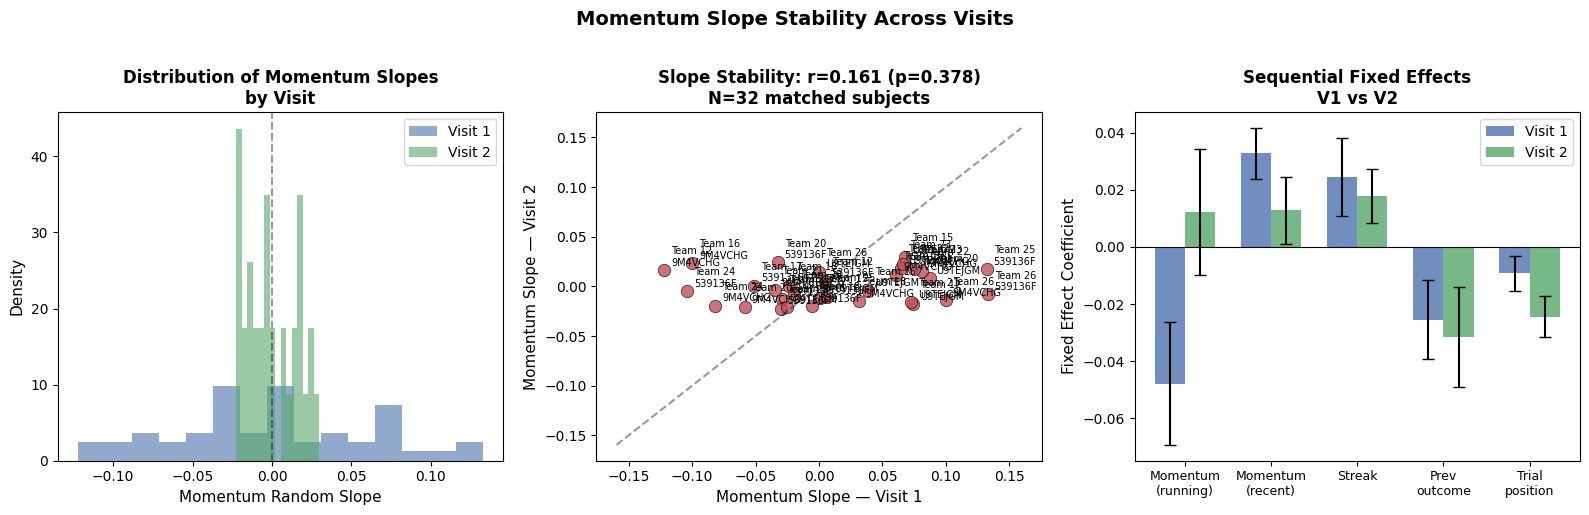

Saved figure.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Random slope distributions by visit
ax = axes[0]
ax.hist(slopes_v1_meta[slope_col].dropna(), bins=15, alpha=0.6, color='#4C72B0', label='Visit 1', density=True)
ax.hist(slopes_v2_meta[slope_col].dropna(), bins=15, alpha=0.6, color='#55A868', label='Visit 2', density=True)
ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Momentum Random Slope', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Momentum Slopes\nby Visit', fontsize=12, fontweight='bold')
ax.legend()

# Panel B: Scatter of matched pairs (if enough)
ax = axes[1]
if len(slope_pairs) >= 3:
    ax.scatter(slope_pairs['slope_v1'], slope_pairs['slope_v2'],
               s=80, alpha=0.8, color='#C44E52', edgecolors='black', linewidth=0.5)
    # Add identity line
    lim = max(abs(slope_pairs[['slope_v1','slope_v2']].values.flatten())) * 1.2
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.4)
    ax.set_xlabel('Momentum Slope — Visit 1', fontsize=11)
    ax.set_ylabel('Momentum Slope — Visit 2', fontsize=11)
    ax.set_title(f'Slope Stability: r={r:.3f} (p={p:.3f})\nN={len(slope_pairs)} matched subjects', fontsize=12, fontweight='bold')
    # Label each point with team+desktop
    for _, row in slope_pairs.iterrows():
        ax.annotate(f"{row['team']}\n{row['desktop_id']}",
                    (row['slope_v1'], row['slope_v2']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
else:
    ax.text(0.5, 0.5, f'Only {len(slope_pairs)} matched\npairs — insufficient\nfor correlation',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('Slope Stability (matched pairs)', fontsize=12, fontweight='bold')

# Panel C: Fixed effects — momentum coefficient V1 vs V2
ax = axes[2]
seq_feats = ['running_invest_rate_z', 'recent_invest_rate_5_z', 'consecutive_same_z',
             'prev_outcome', 'trial_position_z']
fe_seq = fe_compare.loc[fe_compare.index.isin(seq_feats)]
x = np.arange(len(fe_seq))
w = 0.35
ax.bar(x - w/2, fe_seq['coef_v1'], w, yerr=fe_seq['se_v1'], capsize=4,
       label='Visit 1', color='#4C72B0', alpha=0.8)
ax.bar(x + w/2, fe_seq['coef_v2'], w, yerr=fe_seq['se_v2'], capsize=4,
       label='Visit 2', color='#55A868', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Momentum\n(running)', 'Momentum\n(recent)', 'Streak', 'Prev\noutcome', 'Trial\nposition'],
                   fontsize=9)
ax.set_ylabel('Fixed Effect Coefficient', fontsize=11)
ax.set_title('Sequential Fixed Effects\nV1 vs V2', fontsize=12, fontweight='bold')
ax.legend()

plt.suptitle('Momentum Slope Stability Across Visits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'momentum_slope_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

## 4. Ambiguity × Momentum Interaction

Notebook 11 found momentum effects (β=0.021) but never tested whether they vary by ambiguity. Do subjects show stronger momentum bias on easy (low-ambiguity) trials where the decision is clearer, or on hard (high-ambiguity) trials where they may fall back on habit?

In [19]:
# Add interaction term
formula_interact = (
    'outcome ~ running_invest_rate_z * ambiguity_z '
    '+ recent_invest_rate_5_z + consecutive_same_z + prev_outcome + trial_position_z '
    '+ ev_difference_z + risk_premium_z + decision_time_z'
)

formula_no_interact = (
    'outcome ~ running_invest_rate_z + ambiguity_z '
    '+ recent_invest_rate_5_z + consecutive_same_z + prev_outcome + trial_position_z '
    '+ ev_difference_z + risk_premium_z + decision_time_z'
)

print("Fitting no-interaction model (all visits combined)...")
m_no = smf.mixedlm(formula_no_interact, lmm_df, groups=lmm_df['subject_id'])
fit_no = m_no.fit(reml=False, method='lbfgs')

print("Fitting interaction model...")
m_int = smf.mixedlm(formula_interact, lmm_df, groups=lmm_df['subject_id'])
fit_int = m_int.fit(reml=False, method='lbfgs')

# LRT
lr = -2 * (fit_no.llf - fit_int.llf)
p_lrt = chi2.sf(lr, 1)
print(f"\nLRT (interaction term): χ²={lr:.3f}, df=1, p={p_lrt:.4f}")
print(f"Interaction coefficient: {fit_int.params.get('running_invest_rate_z:ambiguity_z', 'N/A')}")

Fitting no-interaction model (all visits combined)...
Fitting interaction model...

LRT (interaction term): χ²=73.690, df=1, p=0.0000
Interaction coefficient: 0.035037456856198725


In [20]:
# Bin ambiguity and show momentum effect per bin
lmm_df['ambiguity_bin'] = pd.cut(lmm_df['ambiguity'], bins=3, labels=['Low','Medium','High'])

momentum_by_ambiguity = []
for amb in ['Low', 'Medium', 'High']:
    sub = lmm_df[lmm_df['ambiguity_bin'] == amb]
    if len(sub) < 100:
        continue
    # Simple logistic regression of momentum on outcome within each ambiguity bin
    from scipy.stats import pointbiserialr
    r_pb, p_pb = pointbiserialr(sub['running_invest_rate_z'], sub['outcome'])
    momentum_by_ambiguity.append({
        'ambiguity': amb,
        'r': r_pb,
        'p': p_pb,
        'n_trials': len(sub)
    })

momentum_amb_df = pd.DataFrame(momentum_by_ambiguity)
print("Momentum-outcome correlation by ambiguity level:")
print(momentum_amb_df.to_string())

Momentum-outcome correlation by ambiguity level:
  ambiguity         r              p  n_trials
0       Low  0.229405   1.895939e-43      3536
1    Medium  0.387935  4.952679e-127      3527
2      High  0.343059   5.985187e-98      3526


In [21]:
# Also break down by visit × ambiguity
lmm_df_visit = lmm_df[lmm_df['visit_number'].isin([1.0, 2.0])].copy()

rows = []
for visit in [1.0, 2.0]:
    for amb in ['Low', 'Medium', 'High']:
        sub = lmm_df_visit[(lmm_df_visit['visit_number'] == visit) & (lmm_df_visit['ambiguity_bin'] == amb)]
        if len(sub) < 50:
            continue
        from scipy.stats import pointbiserialr
        r_pb, p_pb = pointbiserialr(sub['running_invest_rate_z'], sub['outcome'])
        rows.append({'visit': int(visit), 'ambiguity': amb, 'r': r_pb, 'p': p_pb, 'n': len(sub)})

visit_amb_df = pd.DataFrame(rows)
print("Momentum correlation by visit × ambiguity:")
print(visit_amb_df.pivot(index='ambiguity', columns='visit', values='r').round(4))

Momentum correlation by visit × ambiguity:
visit           1       2
ambiguity                
High       0.2789  0.3978
Low        0.1699  0.3088
Medium     0.3086  0.4054


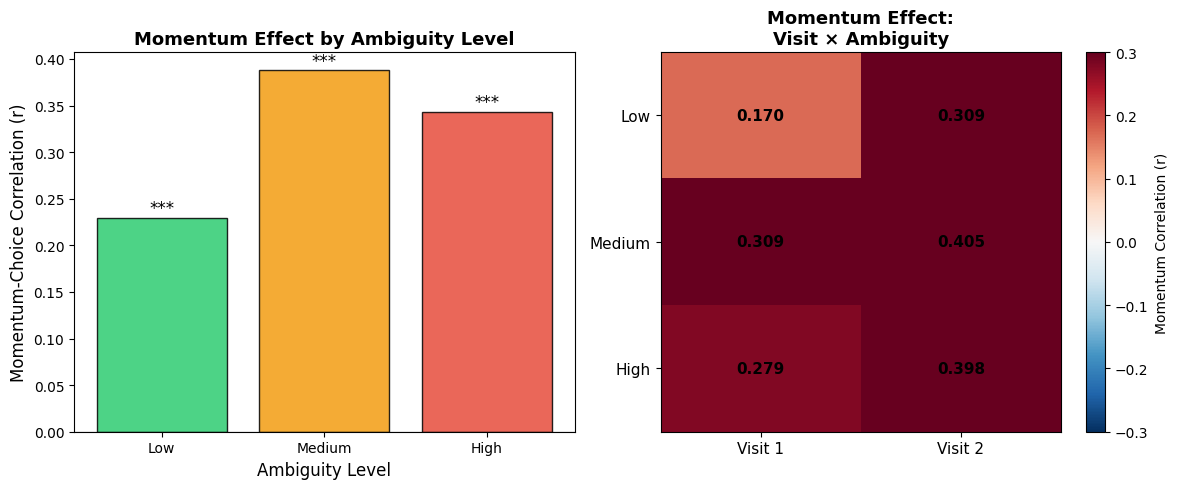

Saved figure.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: momentum correlation by ambiguity
ax = axes[0]
colors_amb = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(momentum_amb_df['ambiguity'], momentum_amb_df['r'],
              color=colors_amb, alpha=0.85, edgecolor='black')
# Add significance stars
for i, row in momentum_amb_df.iterrows():
    star = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'ns'))
    ax.text(i, row['r'] + 0.005, star, ha='center', fontsize=12)
ax.set_xlabel('Ambiguity Level', fontsize=12)
ax.set_ylabel('Momentum-Choice Correlation (r)', fontsize=12)
ax.set_title('Momentum Effect by Ambiguity Level', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)

# Panel B: visit × ambiguity heatmap
ax = axes[1]
if len(visit_amb_df) > 0:
    pivot = visit_amb_df.pivot(index='ambiguity', columns='visit', values='r')
    # Ensure order
    pivot = pivot.reindex(['Low','Medium','High'])
    im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Visit 1', 'Visit 2'], fontsize=11)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=11)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Momentum Correlation (r)')
    ax.set_title('Momentum Effect:\nVisit × Ambiguity', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'momentum_by_ambiguity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

## 5. Summary

In [23]:
print("=" * 60)
print("CROSS-VISIT GENERALIZATION")
print("=" * 60)
print(f"  V1 LOSO (oracle, repeated teams):  {v1_repeated_teams_acc['accuracy'].mean():.4f} ± {v1_repeated_teams_acc['accuracy'].sem():.4f}")
print(f"  V2 LOSO (within-visit baseline):   {res_v2['subject_df']['accuracy'].mean():.4f} ± {res_v2['subject_df']['accuracy'].sem():.4f}")
print(f"  Cross-visit (V1→V2):               {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].sem():.4f}")
print(f"  Δ cross - within: {compare_df['delta'].mean():.4f}, t={t_stat:.3f}, p={p_val:.4f}")

print()
print("=" * 60)
print("MOMENTUM SLOPE STABILITY")
print("=" * 60)
print(f"  V1 momentum fixed effect: {res_lmm_v1.params.get('running_invest_rate_z', 'N/A'):.4f}")
print(f"  V2 momentum fixed effect: {res_lmm_v2.params.get('running_invest_rate_z', 'N/A'):.4f}")
if len(slope_pairs) >= 3:
    print(f"  Slope stability (matched pairs): r={r:.3f}, p={p:.4f}, N={len(slope_pairs)}")
else:
    print(f"  Matched pairs: {len(slope_pairs)} (too few for correlation — see group comparison above)")

print()
print("=" * 60)
print("MOMENTUM × AMBIGUITY INTERACTION")
print("=" * 60)
print(f"  LRT χ²={lr:.3f}, p={p_lrt:.4f}")
print("  Momentum by ambiguity:")
print(momentum_amb_df[['ambiguity','r','p']].to_string(index=False))

# Save summary
summary = {
    'v1_loso_acc': v1_repeated_teams_acc['accuracy'].mean(),
    'v2_loso_acc': res_v2['subject_df']['accuracy'].mean(),
    'cross_visit_acc': cross_df['accuracy_cross'].mean(),
    'cross_vs_within_delta': compare_df['delta'].mean(),
    'cross_vs_within_p': p_val,
    'momentum_lrt_p': p_lrt,
    'n_matched_pairs': len(slope_pairs)
}
pd.Series(summary).to_csv(RESULTS_DIR / 'summary.csv')
print(f"\nResults saved to {RESULTS_DIR}")

CROSS-VISIT GENERALIZATION
  V1 LOSO (oracle, repeated teams):  0.7355 ± 0.0213
  V2 LOSO (within-visit baseline):   0.7456 ± 0.0273
  Cross-visit (V1→V2):               0.7622 ± 0.0249
  Δ cross - within: 0.0165, t=1.893, p=0.0672

MOMENTUM SLOPE STABILITY
  V1 momentum fixed effect: -0.0479
  V2 momentum fixed effect: 0.0124
  Slope stability (matched pairs): r=0.161, p=0.3784, N=32

MOMENTUM × AMBIGUITY INTERACTION
  LRT χ²=73.690, p=0.0000
  Momentum by ambiguity:
ambiguity        r             p
      Low 0.229405  1.895939e-43
   Medium 0.387935 4.952679e-127
     High 0.343059  5.985187e-98

Results saved to ../../data/results/main/cross_visit
